## The ARIMA Model

The ARIMA model is short for the Autoregressive, Integrated Moving Average model.

The ARIMA model is a model that combines the AR and MA building blocks, just as we 
have seen with ARMA in the previous chapter. The addition in ARIMA is the “I” building 
block, which stands for `automatic differencing of non-stationary time series`.

The “I” in ARIMA is for `integrating`. Integrating is a more mathematical synonym 
for differencing a non-stationary time series. In ARIMA, this differencing is not anymore 
done in advance of the modeling phase, but it is done during the model fit.

The data in this example are weekly CO2 data that are available through the 
statsmodels library

In [1]:
import statsmodels.api as sm
data = sm.datasets.co2.load_pandas()
data = data.data
data.head()

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2284 entries, 1958-03-29 to 2001-12-29
Freq: W-SAT
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   co2     2225 non-null   float64
dtypes: float64(1)
memory usage: 35.7 KB


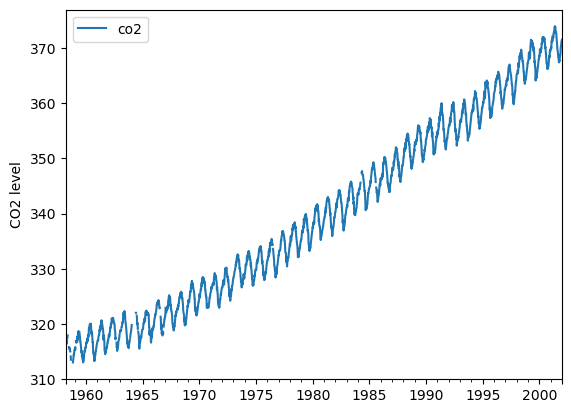

In [3]:
# Plotting the data
import matplotlib.pyplot as plt
ax = data.plot()
ax.set_ylabel('CO2 level')
plt.show()

This data shows a very obvious sign of an upward trend, which is fairly constant. And 
there is also a very clear seasonality pattern in this data (up and down).

So we will apply differencing to make it stationary and check ACF and PACF plots

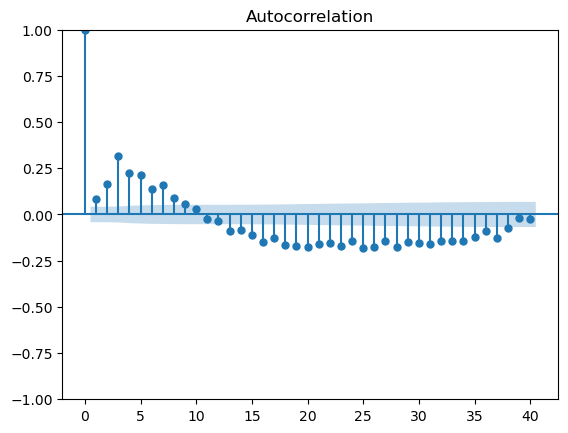

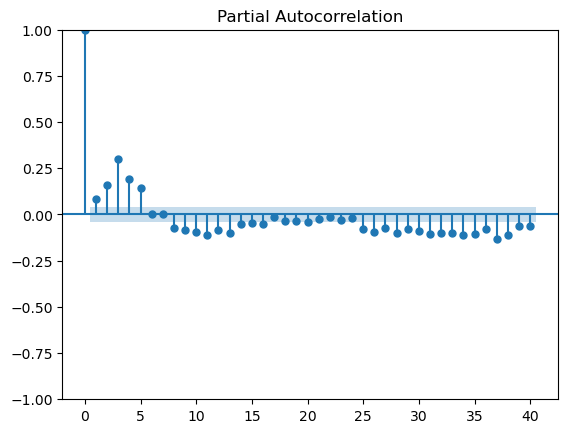

In [4]:
# ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(data.diff().dropna(), lags=40)
plot_pacf(data.diff().dropna(), lags=40)
plt.show()

It is interesting to note that there are many lagged values in the autocorrelation and 
partial autocorrelation. So what does this mean? In general, if there is no decay of the 
correlations toward zero, this means the data is not stationary. Yet the data has been 
differenced and seems stationary.

But notice that the decay in auto-correlation occurs near the ending. This might imply that the number of lags we are trying out might not be enough for this invetigation

Let us try lags=600

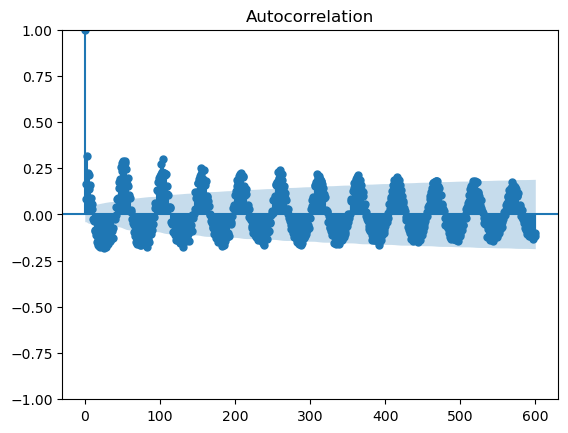

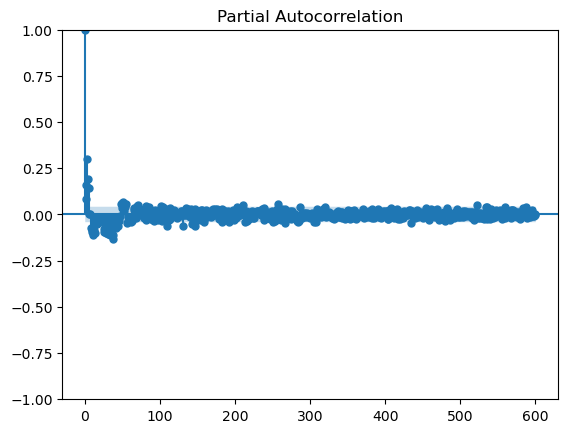

In [5]:
# ACF and PACF plots with more lags
plot_acf(data.diff().dropna(), lags=600)
plot_pacf(data.diff().dropna(), lags=600)
plt.show()

This makes it an interesting case for the question of the order of the model.

We will perform hyperparameter tuning by including 'I' as a third parameter.

In [6]:
data

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4
...,...
2001-12-01,370.3
2001-12-08,370.8
2001-12-15,371.2
2001-12-22,371.3


In [7]:
data[['co2']].values

array([[316.1],
       [317.3],
       [317.6],
       ...,
       [371.2],
       [371.3],
       [371.5]])

In [ ]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore')

data_array = data[['co2']].values

avg_errors = []

for p in range(6):
    for q in range(6):
        for i in range(3)
            errors = []
            tscv = TimeSeriesSplit(test_size=10)

            for train_index, test_index in tscv.split(data_array):
                X_train = data_array[train_index]
                X_test = data_array[test_index]
                X_test_orig = X_test.copy()
                fcst = []

                for step in range(10):
                    try:
                        mod = ARIMA(X_train, order=(p, i, q))
                        res = mod.fit()

                        # Convert forecast from array to scalar
                        forecast = res.forecast(steps=1)[0]
                        fcst.append(forecast)

                    except Exception as e:
                        print(f"Error for p={p}, i={i}, q={q}, step={step}: {e}")

                        # Use a scalar here as well
                        fcst.append(np.nan)

                    # Add actual observation to training data
                    X_train = np.concatenate(
                        (X_train, X_test[0:1, :])
                    )

                    # Remove first test observation
                    X_test = X_test[1:]

                # Convert actual values to 1D
                y_true = X_test_orig.ravel()

                # Convert forecasts to 1D
                y_pred = np.array(fcst)

                # Don't calculate R² if a model failed
                if np.isnan(y_pred).any():
                    errors.append(np.nan)
                else:
                    errors.append(r2_score(y_true, y_pred))

            pq_result = [p, q, np.nanmean(errors)]
            print(pq_result)
            avg_errors.append(pq_result)

In [ ]:
avg_errors = pd.DataFrame(avg_errors)
avg_errors.columns = ['p', 'i', 'q', 'error']
result = avg_errors.pivot(index='p', columns='q')